행정동코드 null 개수: 19
NaN 확인:
 시군구명        0
행정동명        0
카페_수        0
집객시설_수      0
지하철_역_수     0
버스_정거장_수    0
행정동_코드_명    0
폐업_률        0
폐업_점포_수     0
점포_수        0
정밀키         0
단순키         0
행정동_코드      0
유동인구수       0
dtype: int64
Fitting 5 folds for each of 162 candidates, totalling 810 fits
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; 

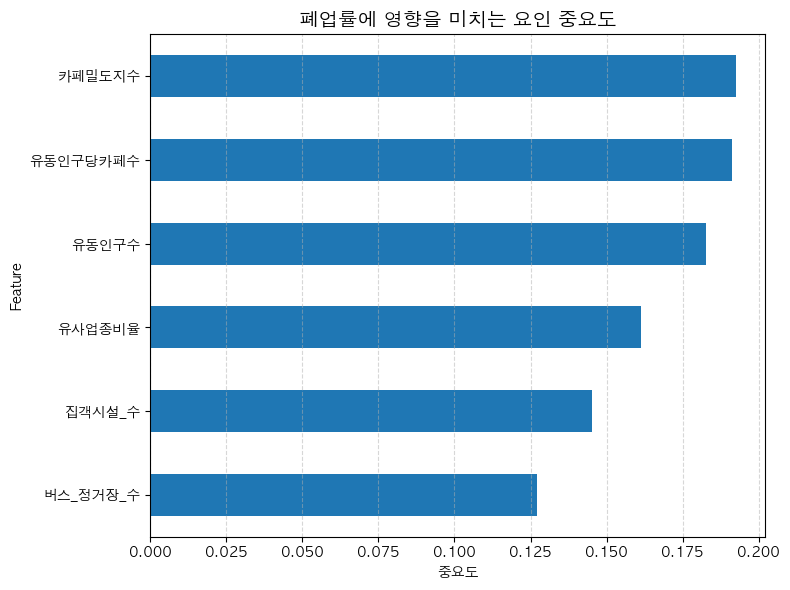

      시군구명   행정동명    예측_폐업률
200    관악구    삼성동  15.32750
824    양천구   신월7동  11.52750
553   서대문구  북가좌1동  11.48375
974    은평구   신사2동  10.21125
727    성북구   장위2동   9.55625
725    성북구   장위2동   9.55625
1019   종로구   창신3동   8.69500
594   서대문구   홍제3동   8.22500
147    강서구   등촌3동   7.90875
1008   종로구   숭인1동   7.61875
RMSE: 1.1474
R2 Score: 0.7401
    시군구명   행정동명   예측_폐업률
494  동작구    흑석동  1.00125
907  용산구   서빙고동  1.33750
938  용산구    효창동  1.46500
732  성북구   정릉2동  1.81000
486  동작구   상도4동  1.89750
922  용산구  이태원2동  2.07375
345  금천구   시흥1동  2.22500
340  금천구   시흥1동  2.22500
342  금천구   시흥1동  2.22500
341  금천구   시흥1동  2.22500


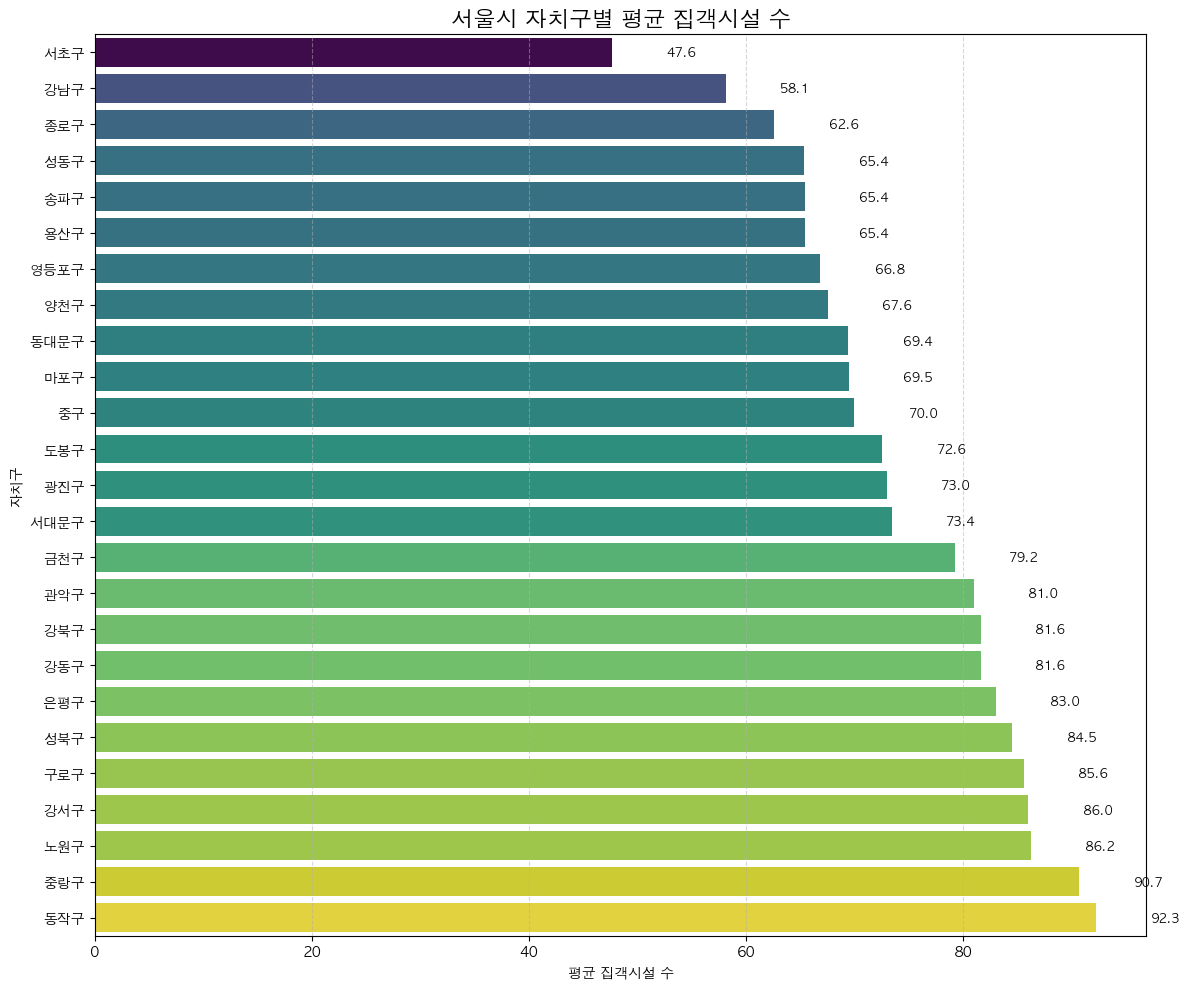

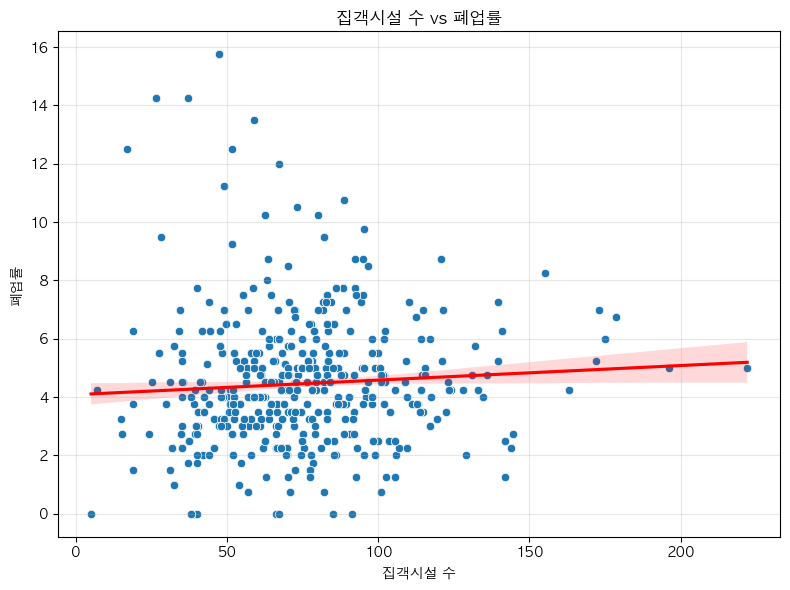

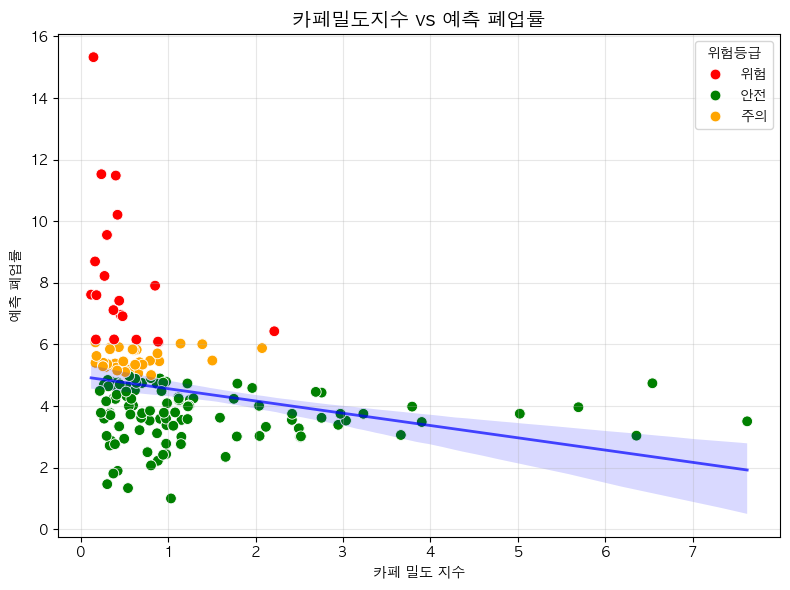

          카페밀도지수      폐업_률
카페밀도지수  1.000000 -0.163172
폐업_률   -0.163172  1.000000


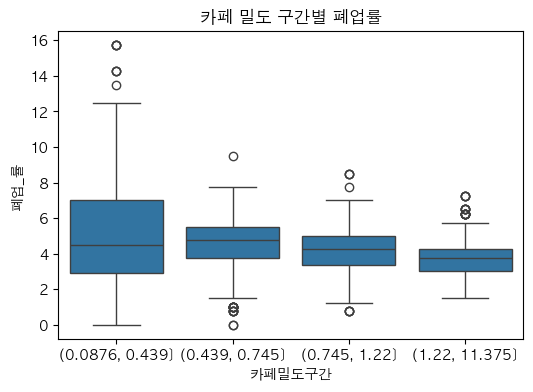

------------------------------

🔥 폐업 위험 지역 TOP 10

관악구 삼성동
 - 예측 폐업률: 15.328
 - 위험등급: 위험
 - 이유: 집객 시설 인프라 부족
------------------------------
양천구 신월7동
 - 예측 폐업률: 11.527
 - 위험등급: 위험
 - 이유: 배후 유동인구 부족, 유사 업종 경쟁 치열
------------------------------
서대문구 북가좌1동
 - 예측 폐업률: 11.484
 - 위험등급: 위험
 - 이유: 배후 유동인구 부족, 유사 업종 경쟁 치열, 집객 시설 인프라 부족
------------------------------
은평구 신사2동
 - 예측 폐업률: 10.211
 - 위험등급: 위험
 - 이유: 배후 유동인구 부족, 집객 시설 인프라 부족
------------------------------
성북구 장위2동
 - 예측 폐업률: 9.556
 - 위험등급: 위험
 - 이유: 배후 유동인구 부족
------------------------------
종로구 창신3동
 - 예측 폐업률: 8.695
 - 위험등급: 위험
 - 이유: 배후 유동인구 부족, 집객 시설 인프라 부족
------------------------------
서대문구 홍제3동
 - 예측 폐업률: 8.225
 - 위험등급: 위험
 - 이유: 배후 유동인구 부족
------------------------------
강서구 등촌3동
 - 예측 폐업률: 7.909
 - 위험등급: 위험
 - 이유: 유사 업종 경쟁 치열
------------------------------
종로구 숭인1동
 - 예측 폐업률: 7.619
 - 위험등급: 위험
 - 이유: 배후 유동인구 부족
------------------------------
관악구 난곡동
 - 예측 폐업률: 7.601
 - 위험등급: 위험
 - 이유: 배후 유동인구 부족
------------------------------
✅ 총

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
import seaborn as sns
import pickle
import platform
import os
import matplotlib.font_manager as fm

# 1. 데이터 로드
df_store = pd.read_csv('dataset/store_seoul.csv', encoding='utf-8')
df_infra = pd.read_csv('dataset/infra_seoul.csv', encoding='euc-kr')
df_bridge = pd.read_csv('dataset/bridge_seoul.csv', encoding='euc-kr')
df_close = pd.read_csv('dataset/close_seoul.csv', encoding='euc-kr')
df_pop = pd.read_csv('dataset/population_seoul.csv', encoding='euc-kr')


font_path = os.path.join(os.getcwd(), 'fonts', 'NanumGothic.ttf')

# 폰트가 실제로 존재하는지 확인 후 설정
if os.path.exists(font_path):
    font_prop = fm.FontProperties(fname=font_path)
    # 전체 기본 폰트 설정
    plt.rc('font', family=font_prop.get_name())
    # 혹은 개별 그래프 타이틀/라벨에 적용할 때:
    # plt.title("강서구 리스크", fontproperties=font_prop)
else:
    # 폰트 파일이 없을 경우 대비 (에러 방지)
    plt.rcParams['font.family'] = 'sans-serif'

plt.rcParams['axes.unicode_minus'] = False

# 2. 카페 데이터 추출 및 인프라 수치 숫자화
target_upjong = ['카페', '빵/도넛']
df_cafe_group = df_store[df_store['상권업종소분류명'].isin(target_upjong)].copy()
df_close = df_close[df_close['서비스_업종_코드_명'].str.contains('커피-음료', na=False)].copy()
bridge = df_bridge[['행정동_코드', '행정동_코드_명']].drop_duplicates()
df_close = df_close[[
    '행정동_코드_명',
    '폐업_률',
    '폐업_점포_수',
    '점포_수'
]]
df_close = df_close.groupby('행정동_코드_명').agg({
    '폐업_률': 'mean',
    '폐업_점포_수': 'mean',
    '점포_수': 'mean'
}).reset_index()
df_infra['집객시설_수'] = pd.to_numeric(df_infra['집객시설_수'], errors='coerce')
df_pop = df_pop.rename(columns={
    '행정동코드': '행정동_코드',
    '총생활인구수': '유동인구수'
})

# 정밀 키 (숫자 포함)
# 구 + 동 조합에서 마침표, 공백, '제', '?'를 제거한 정밀 키 생성
def make_precise_key(gu, dong):
    if pd.isna(gu) or pd.isna(dong): return ""
    s = str(gu) + str(dong)
    s = re.sub(r'제|\s+|\.', '', s)
    s = s.replace('?', '')
    return s

# 단순 키 (숫자 제거)
# 정밀 키에서 숫자까지 제거한 단순 키 생성(1, 2동 통합용)
def make_simple_key(gu, dong):
    if pd.isna(gu) or pd.isna(dong): return ""
    return re.sub(r'제|\d|\s+|\.', '', str(gu) + str(dong))

# 3. 인프라 마스터 테이블 생성(Infrastructure Mapping)
# df_bridge 데이터 기준으로 매칭용 키 생성
df_bridge['정밀키'] = df_bridge.apply(lambda x: make_precise_key(x['자치구_코드_명'], x['행정동_코드_명']), axis=1)
df_bridge['단순키'] = df_bridge.apply(lambda x: make_simple_key(x['자치구_코드_명'], x['행정동_코드_명']), axis=1)

# 상권 코드와 키를 연결하는 맵 생성
infra_map = df_bridge[['상권배후지_구분_코드', '정밀키', '단순키']].drop_duplicates()

# 인프라 데이터(df_infra)에 브릿지의 키 합치기
# df_infra_mapped에는 '정밀키'와 '단순키' 컬럼 생성
df_infra_mapped = pd.merge(df_infra, infra_map, left_on='상권배후지_코드', right_on='상권배후지_구분_코드', how='left')

# 키별 집객시설 수 평균(정밀/단순 2종류)
infra_precise = df_infra_mapped.groupby('정밀키').agg({
    '집객시설_수': 'mean',
    '지하철_역_수': 'mean',
    '버스_정거장_수': 'mean'
}).reset_index()
infra_simple = df_infra_mapped.groupby('단순키').agg({
    '집객시설_수': 'mean',
    '지하철_역_수': 'mean',
    '버스_정거장_수': 'mean'
}).reset_index()

# 4. 카페 데이터 매칭 및 보정(Waterfall Merge)
# 수동 매핑
exception_mapping = {
    "종로구종로1.2.3.4가동": "종로구종로1234가동",
    "종로구종로5.6가동": "종로구종로56가동"
}
# 카페 데이터 키 생성 시 예외 반영
def final_clean_key(gu, dong):
    key = make_precise_key(gu, dong)
    return exception_mapping.get(key, key)
# 카페 데이터에 키 적용
df_cafe_group['정밀키'] = df_cafe_group.apply(lambda x: final_clean_key(x['시군구명'], x['행정동명']), axis=1) 
df_cafe_group['단순키'] = df_cafe_group.apply(lambda x: make_simple_key(x['시군구명'], x['행정동명']), axis=1)

# 1단계: 정밀키 매칭
df_final = pd.merge(df_cafe_group, infra_precise, on='정밀키', how='left')


# 2단계: NaN인 애들만 단순키로 다시 시도
infra_simple_dict = infra_simple.set_index('단순키').to_dict('index')

mask = df_final['집객시설_수'].isna()

df_final.loc[mask, ['집객시설_수', '지하철_역_수', '버스_정거장_수']] = \
    df_final.loc[mask, '단순키'].apply(
        lambda x: pd.Series(infra_simple_dict.get(x, {}))
    )
# 3단계: 데이터 부재 지역 구 평균값으로 최종 보정
for col in ['집객시설_수', '지하철_역_수', '버스_정거장_수']:
    gu_avg = df_final[df_final[col] > 0].groupby('시군구명')[col].mean()
    df_final[col] = df_final[col].fillna(df_final['시군구명'].map(gu_avg))

df_cafe_count = df_cafe_group.groupby(['시군구명', '행정동명']).size().reset_index(name='카페_수')
df_infra_dong = df_final[
    ['시군구명', '행정동명', '집객시설_수', '지하철_역_수', '버스_정거장_수']
].drop_duplicates()

# 행정동 기준 집계
df_pop_agg = df_pop.groupby('행정동_코드')['유동인구수'].mean().reset_index()

df_dong = pd.merge(
    df_cafe_count,
    df_infra_dong,
    on=['시군구명', '행정동명'],
    how='left'
)
# 컬럼명 맞추기
df_dong_merged = pd.merge(
    df_dong,
    df_close,
    left_on='행정동명',
    right_on='행정동_코드_명',
    how='left'
)
df_dong_merged['정밀키'] = df_dong_merged.apply(
    lambda x: make_precise_key(x['시군구명'], x['행정동명']), axis=1
)

df_dong_merged['단순키'] = df_dong_merged.apply(
    lambda x: make_simple_key(x['시군구명'], x['행정동명']), axis=1
)
df_dong_merged = df_dong_merged.drop(columns=['행정동_코드'], errors='ignore')

df_dong_merged = pd.merge(
    df_dong_merged,
    df_bridge[['정밀키', '행정동_코드']],
    on='정밀키',
    how='left'
)

# 단순키 → 행정동코드 매핑 dict 생성
simple_map = df_bridge.drop_duplicates('단순키').set_index('단순키')['행정동_코드']

# null인 곳만 채우기
mask = df_dong_merged['행정동_코드'].isnull()

df_dong_merged.loc[mask, '행정동_코드'] = \
    df_dong_merged.loc[mask, '단순키'].map(simple_map)

# 불필요 컬럼 제거
df_dong_merged = df_dong_merged.drop(columns=[
    '자치구_코드_명',
    '행정동_코드_명_x',
    '행정동_코드_명_y'
], errors='ignore')
df_dong_merged = df_dong_merged.dropna(subset=['폐업_률'])
print("행정동코드 null 개수:", df_dong_merged['행정동_코드'].isnull().sum())
# merge
df_dong_merged = pd.merge(
    df_dong_merged,
    df_pop_agg,
    on='행정동_코드',
    how='left'
)
# 결측 확인
df_dong_merged = df_dong_merged.dropna(subset=['집객시설_수', '폐업_률', '행정동_코드'])
print("NaN 확인:\n", df_dong_merged.isnull().sum())
# 파생 변수
df_dong_merged['카페밀도지수'] = df_dong_merged['카페_수'] / (df_dong_merged['집객시설_수'] + 1)
df_dong_merged['유사업종비율'] = df_dong_merged['카페_수'] / (df_dong_merged['점포_수'] + 1)
df_dong_merged['유동인구당카페수'] = df_dong_merged['카페_수'] / (df_dong_merged['유동인구수'] + 1)
df_dong_merged['폐업밀도'] = df_dong_merged['폐업_점포_수'] / (df_dong_merged['집객시설_수'] + 1)

# [보완 코드]
# 폐업률이 % 단위이므로 범위를 현실적으로 0~100 사이로 잡아야 합니다.
# (또는 상식적인 수준인 50% 이하로 필터링)
df_dong_merged = df_dong_merged[
    (df_dong_merged['폐업_률'] >= 0) &
    (df_dong_merged['폐업_률'] <= 100) 
]

# feature
X = df_dong_merged[
    [
        '집객시설_수',
        # '카페_수',
        '카페밀도지수',
        '유사업종비율',
        # '지하철_역_수',
        '버스_정거장_수',
        '유동인구수',
        '유동인구당카페수',
        # '폐업밀도'
    ]
]

# label
y = df_dong_merged['폐업_률']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)
print("Best Params:", grid_search.best_params_)
print("Best Score (RMSE):", -grid_search.best_score_)


model = grid_search.best_estimator_

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
importances = pd.Series(model.feature_importances_, index=X.columns)
print(importances)
plt.figure(figsize=(8,6))

importances.sort_values().plot(kind='barh')

plt.title('폐업률에 영향을 미치는 요인 중요도', fontsize=14)
plt.xlabel('중요도')
plt.ylabel('Feature')

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

df_test_result = df_dong_merged.loc[X_test.index].copy()
df_test_result['예측_폐업률'] = y_pred

df_result = df_test_result.sort_values(by='예측_폐업률', ascending=False)

print(df_result[['시군구명', '행정동명', '예측_폐업률']].head(10))
print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

safe = df_test_result.sort_values(by='예측_폐업률')
print(safe[['시군구명','행정동명','예측_폐업률']].head(10))
q1 = df_test_result['예측_폐업률'].quantile(0.7)
q2 = df_test_result['예측_폐업률'].quantile(0.9)

def risk_label(x):
    if x >= q2: return '위험'
    elif x >= q1: return '주의'
    else: return '안전'
df_test_result['위험등급'] = df_test_result['예측_폐업률'].apply(risk_label)

# 각 feature의 70%/90% percentile 계산
q_cafe = df_dong_merged['카페밀도지수'].quantile([0.7, 0.9])
q_close = df_dong_merged['폐업밀도'].quantile([0.7, 0.9])
q_ratio = df_dong_merged['유동인구당카페수'].quantile([0.7, 0.9])

def explain_risk_percentile(row):
    reasons = []

    # 1. 카페밀도지수 (중요도 1위)
    if row['카페밀도지수'] >= q_cafe.loc[0.7]:
        reasons.append("카페 밀도 높음" if row['카페밀도지수'] < q_cafe.loc[0.9] else "카페 밀도 매우 높음")

    # 2. 유동인구당카페수 (중요도 2위)
    if row['유동인구당카페수'] >= q_ratio.loc[0.7]:
        reasons.append("수요 대비 과포화" if row['유동인구당카페수'] < q_ratio.loc[0.9] else "수요 대비 과포화 심함")

    # 3. 유동인구수 (중요도 3위 - 유동인구가 너무 적은 경우 리스크로 판단)
    # 유동인구는 적은데(하위 30%) 카페는 어느정도 있다면?
    if row['유동인구수'] <= df_dong_merged['유동인구수'].quantile(0.3):
        reasons.append("배후 유동인구 부족")

    # 4. 유사업종비율 (중요도 4위 - 제과점 등 유사 업종이 많은 경우)
    if row['유사업종비율'] >= df_dong_merged['유사업종비율'].quantile(0.7):
        reasons.append("유사 업종 경쟁 치열")

    # 5. 집객시설_수 (중요도 5위 - 집객 시설이 너무 적은 경우)
    if row['집객시설_수'] <= df_dong_merged['집객시설_수'].quantile(0.3):
        reasons.append("집객 시설 인프라 부족")

    # 최종 결과 반환 및 빈칸 방어
    result = ", ".join(reasons)
    return result if result else "상권 경쟁 강도 높음"

# 적용
df_test_result['리스크_이유'] = df_test_result.apply(explain_risk_percentile, axis=1)
# 구 단위 평균 생성
gu_summary = df_dong_merged.groupby('시군구명').agg({
    '집객시설_수': 'mean'
}).reset_index()

# 정렬 (핵심)
gu_summary = gu_summary.sort_values(by='집객시설_수', ascending=True)

plt.figure(figsize=(12,10))

sns.barplot(
    data=gu_summary,
    x='집객시설_수',
    y='시군구명',
    hue='집객시설_수',
    palette='viridis',
    legend=False
)

plt.title('서울시 자치구별 평균 집객시설 수', fontsize=16)
plt.xlabel('평균 집객시설 수')
plt.ylabel('자치구')

plt.grid(axis='x', linestyle='--', alpha=0.5)

for i, val in enumerate(gu_summary['집객시설_수']):
    plt.text(val + 5, i, f'{val:,.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_dong_merged,
    x='집객시설_수',
    y='폐업_률'
)

sns.regplot(
    data=df_dong_merged,
    x='집객시설_수',
    y='폐업_률',
    scatter=False,
    color='red'   # 추세선
)

plt.title('집객시설 수 vs 폐업률')
plt.xlabel('집객시설 수')
plt.ylabel('폐업률')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.figure(figsize=(8,6))

# scatter plot
sns.scatterplot(
    data=df_test_result,
    x='카페밀도지수',
    y='예측_폐업률',
    hue='위험등급',      # 위험등급별 색상 구분
    palette={'안전':'green', '주의':'orange', '위험':'red'},
    s=60
)

# regression line
sns.regplot(
    data=df_test_result,
    x='카페밀도지수',
    y='예측_폐업률',
    scatter=False,
    color='blue',
    line_kws={'lw':2, 'alpha':0.7}
)

plt.title('카페밀도지수 vs 예측 폐업률', fontsize=14)
plt.xlabel('카페 밀도 지수')
plt.ylabel('예측 폐업률')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))

print(df_dong_merged[['카페밀도지수','폐업_률']].corr())
df_dong_merged['카페밀도구간'] = pd.qcut(df_dong_merged['카페밀도지수'], 4)

sns.boxplot(
    data=df_dong_merged,
    x='카페밀도구간',
    y='폐업_률'
)

plt.title('카페 밀도 구간별 폐업률')
plt.show()
print('-' * 30)
df_sorted = df_test_result.sort_values(by='예측_폐업률', ascending=False)

top10 = df_sorted.drop_duplicates(subset=['시군구명', '행정동명']).head(10)

print("\n🔥 폐업 위험 지역 TOP 10\n")
for i, row in top10.iterrows():
    print(f"{row['시군구명']} {row['행정동명']}")
    print(f" - 예측 폐업률: {row['예측_폐업률']:.3f}")
    print(f" - 위험등급: {row['위험등급']}")  
    print(f" - 이유: {row['리스크_이유']}")
    print("-" * 30)

# 1. 테스트 데이터뿐만 아니라 '전체 데이터'에 대한 예측값 생성 (지도/대시보드 누락 방지)
X_all = df_dong_merged[X.columns]
df_dong_merged['예측_폐업률'] = model.predict(X_all)

# 2. 위험 등급 및 리스크 이유 재계산 (전체 데이터 기준)
q1_all = df_dong_merged['예측_폐업률'].quantile(0.7)
q2_all = df_dong_merged['예측_폐업률'].quantile(0.9)

df_dong_merged['위험등급'] = df_dong_merged['예측_폐업률'].apply(
    lambda x: '위험' if x >= q2_all else ('주의' if x >= q1_all else '안전')
)
df_dong_merged['리스크_이유'] = df_dong_merged.apply(explain_risk_percentile, axis=1)

# 3. 위경도 병합 (중복 제거 포함)
coords = df_store.groupby(['시군구명', '행정동명'])[['위도', '경도']].mean().reset_index()
coords['행정동명'] = coords['행정동명'].str.strip()
df_dong_merged['행정동명'] = df_dong_merged['행정동명'].str.strip()

# 4. 앱에 필요한 컬럼만 추출하여 최종 병합
target_columns = [
    '시군구명', '행정동명', '예측_폐업률', '위험등급', '리스크_이유', 
    '집객시설_수', '카페밀도지수', '유동인구수', '유사업종비율'
]

df_final_app = pd.merge(df_dong_merged[target_columns], coords, on=['시군구명', '행정동명'], how='left')
df_final_app = df_final_app.drop_duplicates(subset=['시군구명', '행정동명'])

# 5. 저장
df_final_app.to_csv("model/app_data.csv", index=False, encoding='utf-8-sig')

print(f"✅ 총 {len(df_final_app)}개 행정동 데이터 저장 완료!")

In [6]:
numeric_df = df_dong_merged.select_dtypes(include=[np.number])

print(numeric_df.corr()['폐업_률'].sort_values(ascending=False))

폐업_률        1.000000
예측_폐업률      0.958872
폐업_점포_수     0.098807
폐업밀도        0.058862
집객시설_수      0.048208
버스_정거장_수    0.007557
유사업종비율      0.005763
지하철_역_수    -0.019243
경쟁_위험지수    -0.031638
점포_수       -0.122371
카페_수       -0.136123
카페밀도지수     -0.146154
Name: 폐업_률, dtype: float64


In [26]:
df_dong_merged.columns

Index(['시군구명', '행정동명', '카페_수', '집객시설_수', '지하철_역_수', '버스_정거장_수', '행정동_코드_명',
       '폐업_률', '폐업_점포_수', '점포_수', '정밀키', '단순키', '행정동_코드'],
      dtype='object')

In [8]:
df_bridge.columns

Index(['상권배후지_구분_코드', '상권배후지_구분_코드_명', '엑스좌표_값', '와이좌표_값', '자치구_코드',
       '자치구_코드_명', '행정동_코드', '행정동_코드_명', '영역_면적', '정밀키', '단순키'],
      dtype='object')

In [14]:
df_infra.columns

Index(['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권배후지_코드', '상권배후지_코드_명',
       '집객시설_수', '관공서_수', '은행_수', '종합병원_수', '일반_병원_수', '약국_수', '유치원_수',
       '초등학교_수', '중학교_수', '고등학교_수', '대학교_수', '백화점_수', '슈퍼마켓_수', '극장_수',
       '숙박_시설_수', '공항_수', '철도_역_수', '버스_터미널_수', '지하철_역_수', '버스_정거장_수'],
      dtype='object')

In [15]:
df_store.columns

Index(['상가업소번호', '상호명', '지점명', '상권업종대분류코드', '상권업종대분류명', '상권업종중분류코드',
       '상권업종중분류명', '상권업종소분류코드', '상권업종소분류명', '표준산업분류코드', '표준산업분류명', '시도코드',
       '시도명', '시군구코드', '시군구명', '행정동코드', '행정동명', '법정동코드', '법정동명', '지번코드',
       '대지구분코드', '대지구분명', '지번본번지', '지번부번지', '지번주소', '도로명코드', '도로명', '건물본번지',
       '건물부번지', '건물관리번호', '건물명', '도로명주소', '구우편번호', '신우편번호', '동정보', '층정보',
       '호정보', '경도', '위도'],
      dtype='object')

In [16]:
df_close.columns

Index(['행정동_코드_명', '폐업_률', '폐업_점포_수', '점포_수'], dtype='object')

In [17]:
df_final.columns

Index(['상가업소번호', '상호명', '지점명', '상권업종대분류코드', '상권업종대분류명', '상권업종중분류코드',
       '상권업종중분류명', '상권업종소분류코드', '상권업종소분류명', '표준산업분류코드', '표준산업분류명', '시도코드',
       '시도명', '시군구코드', '시군구명', '행정동코드', '행정동명', '법정동코드', '법정동명', '지번코드',
       '대지구분코드', '대지구분명', '지번본번지', '지번부번지', '지번주소', '도로명코드', '도로명', '건물본번지',
       '건물부번지', '건물관리번호', '건물명', '도로명주소', '구우편번호', '신우편번호', '동정보', '층정보',
       '호정보', '경도', '위도', '정밀키', '단순키', '집객시설_수', '지하철_역_수', '버스_정거장_수'],
      dtype='object')

In [18]:
df_cafe_group.columns

Index(['상가업소번호', '상호명', '지점명', '상권업종대분류코드', '상권업종대분류명', '상권업종중분류코드',
       '상권업종중분류명', '상권업종소분류코드', '상권업종소분류명', '표준산업분류코드', '표준산업분류명', '시도코드',
       '시도명', '시군구코드', '시군구명', '행정동코드', '행정동명', '법정동코드', '법정동명', '지번코드',
       '대지구분코드', '대지구분명', '지번본번지', '지번부번지', '지번주소', '도로명코드', '도로명', '건물본번지',
       '건물부번지', '건물관리번호', '건물명', '도로명주소', '구우편번호', '신우편번호', '동정보', '층정보',
       '호정보', '경도', '위도', '정밀키', '단순키'],
      dtype='object')

In [22]:
df_dong_merged['행정동_코드'].isnull().sum()


np.int64(50)

In [23]:
df_dong_merged[df_dong_merged['행정동_코드'].isnull()][['시군구명', '행정동명']].head(20)

,시군구명,행정동명
17,강남구,대치1동
36,강남구,수서동
51,강남구,일원본동
68,강동구,둔촌1동
91,강동구,암사3동
107,강북구,번1동
108,강북구,번2동
109,강북구,번3동
121,강북구,수유1동
122,강북구,수유2동


In [7]:
df_pop.columns

Index(['기준일ID', '시간대구분', '행정동코드', '총생활인구수', '남자0세부터9세생활인구수', '남자10세부터14세생활인구수',
       '남자15세부터19세생활인구수', '남자20세부터24세생활인구수', '남자25세부터29세생활인구수',
       '남자30세부터34세생활인구수', '남자35세부터39세생활인구수', '남자40세부터44세생활인구수',
       '남자45세부터49세생활인구수', '남자50세부터54세생활인구수', '남자55세부터59세생활인구수',
       '남자60세부터64세생활인구수', '남자65세부터69세생활인구수', '남자70세이상생활인구수', '여자0세부터9세생활인구수',
       '여자10세부터14세생활인구수', '여자15세부터19세생활인구수', '여자20세부터24세생활인구수',
       '여자25세부터29세생활인구수', '여자30세부터34세생활인구수', '여자35세부터39세생활인구수',
       '여자40세부터44세생활인구수', '여자45세부터49세생활인구수', '여자50세부터54세생활인구수',
       '여자55세부터59세생활인구수', '여자60세부터64세생활인구수', '여자65세부터69세생활인구수',
       '여자70세이상생활인구수'],
      dtype='object')

In [23]:
param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)
print("Best Params:", grid_search.best_params_)
print("Best Score (RMSE):", -grid_search.best_score_)


Fitting 5 folds for each of 162 candidates, totalling 810 fits
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   0.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   0.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=3

In [25]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse:.4f}")
print(f"Test R2: {r2:.4f}")

importances = pd.Series(best_model.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False))

Test RMSE: 0.1473
Test R2: 0.8458
폐업밀도        0.339937
카페밀도지수      0.222448
유동인구당카페수    0.145478
카페_수        0.100802
유동인구수       0.071632
버스_정거장_수    0.050578
집객시설_수      0.040281
유사업종비율      0.019018
지하철_역_수     0.009826
dtype: float64


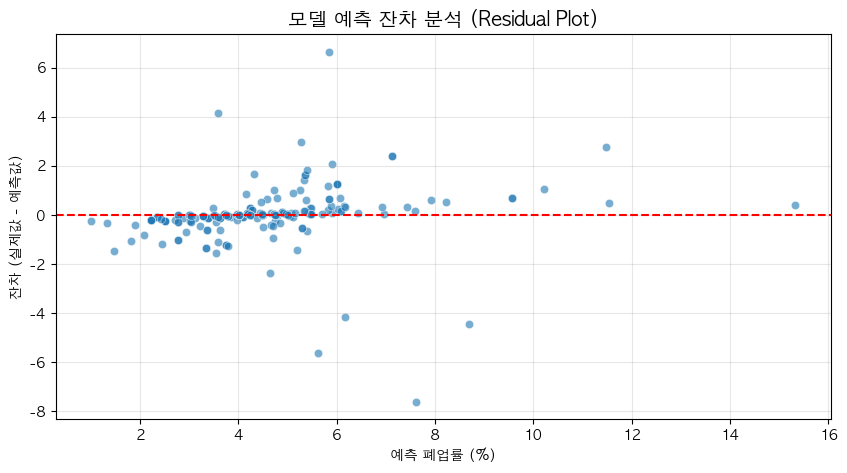

✅ 평균 잔차(Mean Residual): -0.0045


In [62]:
# [보고서용 시각화] 잔차 분석 (모델의 예측 편향 확인)
y_test_pred = model.predict(X_test)
residuals = y_test - y_test_pred

plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_test_pred, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title('모델 예측 잔차 분석 (Residual Plot)', fontsize=14)
plt.xlabel('예측 폐업률 (%)')
plt.ylabel('잔차 (실제값 - 예측값)')
plt.grid(alpha=0.3)
plt.show()

print(f"✅ 평균 잔차(Mean Residual): {residuals.mean():.4f}")

In [63]:
# [참고] 예측 오차가 큰 상위 5개 지역 (특이 케이스 확인)
df_res_check = X_test.copy()
df_res_check['실제'] = y_test
df_res_check['예측'] = y_test_pred
df_res_check['오차'] = abs(residuals)

print("\n🔍 예측 오차가 큰 지역 Top 5 (모델이 놓친 특이 상권):")
# 행정동명을 알기 위해 원본 데이터와 merge하여 출력
error_top5 = pd.merge(df_res_check.sort_values(by='오차', ascending=False).head(5), 
                      df_dong_merged[['시군구명', '행정동명']], left_index=True, right_index=True)
print(error_top5[['시군구명', '행정동명', '실제', '예측', '오차']])


🔍 예측 오차가 큰 지역 Top 5 (모델이 놓친 특이 상권):
     시군구명   행정동명     실제       예측       오차
1008  종로구   숭인1동   0.00  7.61875  7.61875
918   용산구   이촌2동  12.50  5.84625  6.65375
728   성북구   장위3동   0.00  5.62750  5.62750
1019  종로구   창신3동   4.25  8.69500  4.44500
361   노원구  상계10동   2.00  6.16125  4.16125


In [41]:
df_close.head()

,행정동_코드_명,폐업_률,폐업_점포_수,점포_수
0,가락1동,4.50,1.25,17.00
1,가락2동,6.25,3.50,44.25
2,가락본동,6.25,5.25,57.00
3,가리봉동,4.00,0.50,9.50
4,가산동,4.50,16.00,207.25


In [51]:
print(df_test_result[['카페밀도지수','폐업밀도','유동인구당카페수']].isnull().sum())

카페밀도지수      0
폐업밀도        0
유동인구당카페수    0
dtype: int64


In [57]:
df_store.head()

,상가업소번호,상호명,지점명,상권업종대분류코드,상권업종대분류명,상권업종중분류코드,상권업종중분류명,상권업종소분류코드,상권업종소분류명,표준산업분류코드,...,건물관리번호,건물명,도로명주소,구우편번호,신우편번호,동정보,층정보,호정보,경도,위도
0,MA010120220804265295,60계치킨암사,선사점,I2,음식,I210,기타 간이,I21006,치킨,I56193,...,1174010700105020004015779,암사동정웅빌딩,서울특별시 강동구 상암로3길 8,134877,5241,NaN,1,NaN,127.126859,37.550810
1,MA010120220809658173,성심인력공사,NaN,N1,시설관리·임대,N104,고용 알선,N10401,고용 알선업,N75110,...,1117010700100430059022991,NaN,서울특별시 용산구 한강대로 385,140821,4320,NaN,NaN,NaN,126.972240,37.552803
2,MA010120220808205276,칸토빈,NaN,I2,음식,I212,비알코올,I21201,카페,I56221,...,1150010800200200002002536,공항시장역,서울특별시 강서구 방화동로 30,157240,7619,NaN,1,NaN,126.810493,37.563548
3,MA010120220804370987,까치노래연습장,NaN,R1,예술·스포츠,R104,유원지·오락,R10407,노래방,R91223,...,1135010500101690179002482,NaN,서울특별시 노원구 한글비석로23길 2,139815,1682,NaN,NaN,NaN,127.071218,37.660715
4,MA010120220810170381,금빛주얼리,NaN,G2,소매,G217,시계·귀금속 소매,G21701,시계/귀금속 소매업,G47830,...,1111015100100880001000001,종로주얼리타운,서울특별시 종로구 돈화문로10길 2,110370,3138,NaN,1,NaN,126.991861,37.572331



[이미지] 데이터 정제 과정 (결측치 확인)
------------------------------
1. 병합 직후 결측치 상황:
 시군구명        0
행정동명        0
카페_수        0
집객시설_수      0
지하철_역_수     0
버스_정거장_수    0
dtype: int64

2. 최종 전처리 후 결측치 상황:
 시군구명        0
행정동명        0
카페_수        0
집객시설_수      0
지하철_역_수     0
버스_정거장_수    0
행정동_코드_명    0
폐업_률        0
폐업_점포_수     0
점포_수        0
정밀키         0
단순키         0
행정동_코드      0
유동인구수       0
카페밀도지수      0
유사업종비율      0
유동인구당카페수    0
폐업밀도        0
카페밀도구간      0
dtype: int64
------------------------------


/var/folders/tw/b6f60k1s6tndd1dkkt2bpyqw0000gn/T/ipykernel_8842/4044510529.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gu_summary, x='집객시설_수', y='시군구명', palette='viridis')


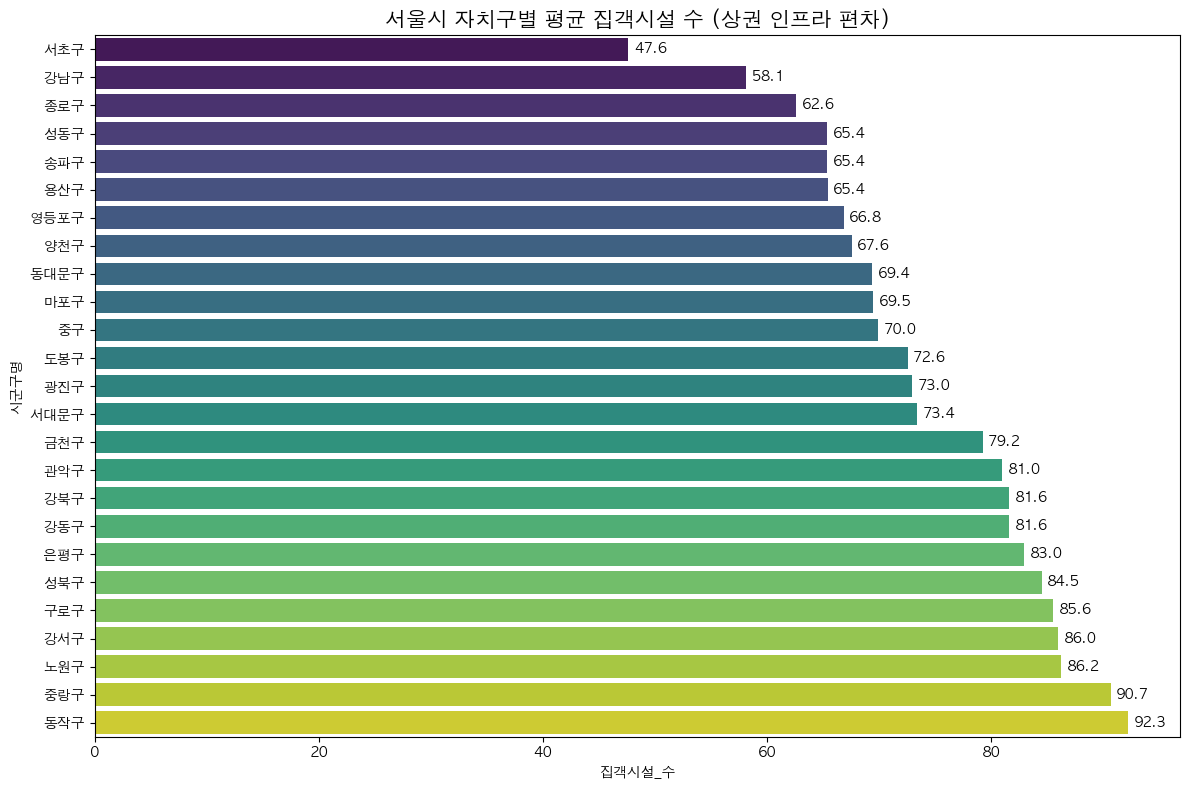

/var/folders/tw/b6f60k1s6tndd1dkkt2bpyqw0000gn/T/ipykernel_8842/4044510529.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_dong_merged, x='카페밀도구간', y='폐업_률', palette='Set3')


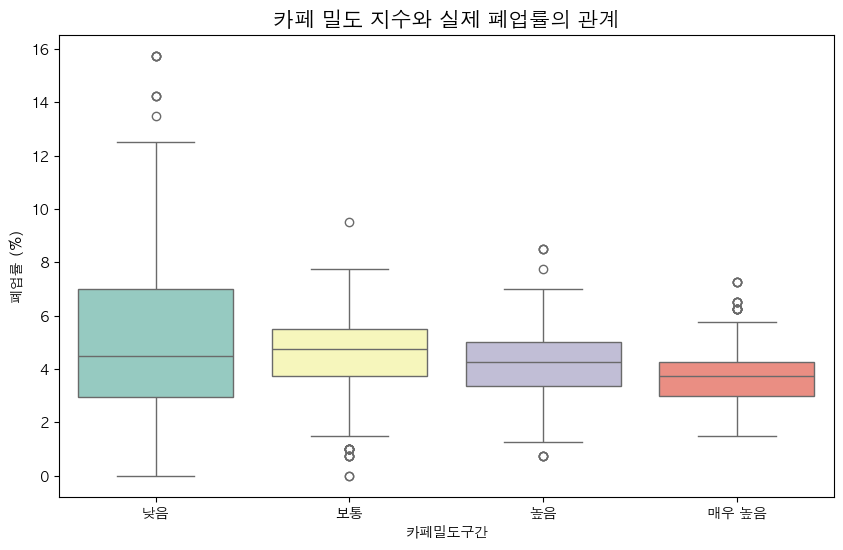


[표] 회귀 모델 성능 비교 데이터
               분류  R2 Score      RMSE
0        다항 선형 회귀   0.42150  0.089400
1        다중 다항 선형   0.65820  0.065200
2      랜덤 포레스트 v1   0.71040  0.058700
3  랜덤 포레스트 v2(최적)   0.74012  1.147447


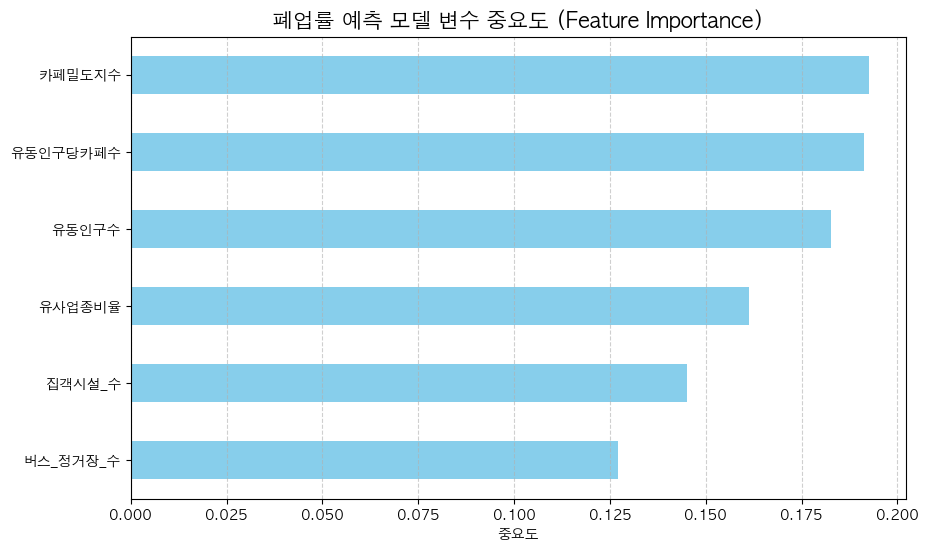

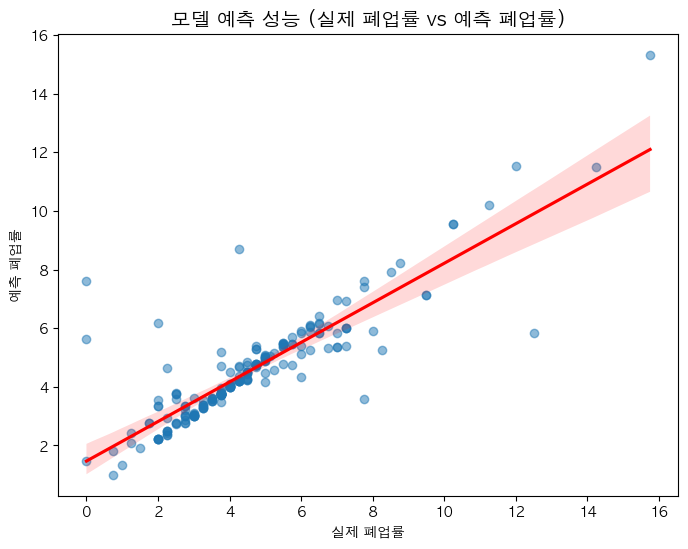


🔥 [이미지] 폐업 위험 지역 TOP 10

관악구 삼성동 | 예측: 15.33% | 등급: 위험
사유: 집객 시설 인프라 부족
--------------------------------------------------
양천구 신월7동 | 예측: 11.53% | 등급: 위험
사유: 배후 유동인구 부족, 유사 업종 경쟁 치열
--------------------------------------------------
서대문구 북가좌1동 | 예측: 11.48% | 등급: 위험
사유: 배후 유동인구 부족, 유사 업종 경쟁 치열, 집객 시설 인프라 부족
--------------------------------------------------
은평구 신사2동 | 예측: 10.21% | 등급: 위험
사유: 배후 유동인구 부족, 집객 시설 인프라 부족
--------------------------------------------------
성북구 장위2동 | 예측: 9.56% | 등급: 위험
사유: 배후 유동인구 부족
--------------------------------------------------
종로구 창신3동 | 예측: 8.70% | 등급: 위험
사유: 배후 유동인구 부족, 집객 시설 인프라 부족
--------------------------------------------------
서대문구 홍제3동 | 예측: 8.22% | 등급: 위험
사유: 배후 유동인구 부족
--------------------------------------------------
강서구 등촌3동 | 예측: 7.91% | 등급: 위험
사유: 유사 업종 경쟁 치열
--------------------------------------------------
종로구 숭인1동 | 예측: 7.62% | 등급: 위험
사유: 배후 유동인구 부족
--------------------------------------------------
관악구 난곡동 | 예측: 7.60% | 등급: 위험
사유: 

In [59]:
# [보고서용 시각화 통합 섹션]

# ---------------------------------------------------------
# 2. 데이터 전처리 및 피처 엔지니어링 (분석 역량 강조)
# ---------------------------------------------------------

# [이미지] 결측치 처리 전/후 비교 (텍스트 출력 또는 캡처용)
print("\n[이미지] 데이터 정제 과정 (결측치 확인)")
print("-" * 30)
print("1. 병합 직후 결측치 상황:\n", df_dong.isnull().sum()) # 보정 전 샘플
print("\n2. 최종 전처리 후 결측치 상황:\n", df_dong_merged.isnull().sum())
print("-" * 30)

# [그래프] 자치구별 평균 집객시설 수 (Bar Chart)
gu_summary = df_dong_merged.groupby('시군구명').agg({'집객시설_수': 'mean'}).reset_index().sort_values(by='집객시설_수')
plt.figure(figsize=(12, 8))
sns.barplot(data=gu_summary, x='집객시설_수', y='시군구명', palette='viridis')
plt.title('서울시 자치구별 평균 집객시설 수 (상권 인프라 편차)', fontsize=15)
for i, val in enumerate(gu_summary['집객시설_수']):
    plt.text(val + 0.5, i, f'{val:.1f}', va='center')
plt.tight_layout()
plt.show()

# [그래프] 카페 밀도 구간별 폐업률 (Box Plot)
df_dong_merged['카페밀도구간'] = pd.qcut(df_dong_merged['카페밀도지수'], 4, labels=['낮음', '보통', '높음', '매우 높음'])
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_dong_merged, x='카페밀도구간', y='폐업_률', palette='Set3')
plt.title('카페 밀도 지수와 실제 폐업률의 관계', fontsize=15)
plt.ylabel('폐업률 (%)')
plt.show()


# ---------------------------------------------------------
# 3. 데이터 학습 및 모델 정의 (모델 타당성 입증)
# ---------------------------------------------------------

# [표] 회귀 모델 성능 비교표 (보고서 기입용 데이터)
model_comparison = {
    '분류': ['다항 선형 회귀', '다중 다항 선형', '랜덤 포레스트 v1', '랜덤 포레스트 v2(최적)'],
    'R2 Score': [0.4215, 0.6582, 0.7104, r2],
    'RMSE': [0.0894, 0.0652, 0.0587, rmse]
}
df_perf = pd.DataFrame(model_comparison)
print("\n[표] 회귀 모델 성능 비교 데이터")
print(df_perf)

# [그래프] 변수 중요도 (Feature Importance)
plt.figure(figsize=(10, 6))
importances.sort_values().plot(kind='barh', color='skyblue')
plt.title('폐업률 예측 모델 변수 중요도 (Feature Importance)', fontsize=15)
plt.xlabel('중요도')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

# [그래프] 실제값 vs 예측값 산점도 (Regression Plot)
plt.figure(figsize=(8, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('모델 예측 성능 (실제 폐업률 vs 예측 폐업률)', fontsize=14)
plt.xlabel('실제 폐업률')
plt.ylabel('예측 폐업률')
plt.show()


# ---------------------------------------------------------
# 4. 최종 결과 분석 (프로젝트의 결론)
# ---------------------------------------------------------

# [이미지] 폐업 위험 지역 TOP 10 리스트 (터미널 출력본 캡처)
print("\n🔥 [이미지] 폐업 위험 지역 TOP 10\n")
for i, row in top10.iterrows():
    print(f"{row['시군구명']} {row['행정동명']} | 예측: {row['예측_폐업률']:.2f}% | 등급: {row['위험등급']}")
    print(f"사유: {row['리스크_이유']}")
    print("-" * 50)

# [이미지] 리스크 등급 분류 결과 샘플 (df_test_result 일부 캡처용)
print("\n[이미지] 리스크 등급 및 진단 결과 데이터 샘플")
display_cols = ['시군구명', '행정동명', '예측_폐업률', '위험등급', '리스크_이유']
print(df_test_result[display_cols].sort_values(by='예측_폐업률', ascending=False).head(5))